# Manuscript figures

In [ ]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import os
# only load this one time per session
if 'NOTEBOOK_INITIALIZED' not in globals():
    os.chdir(os.path.dirname(os.path.abspath('.')))
    NOTEBOOK_INITIALIZED = True

import seaborn as sns
import matplotlib.pyplot as plt
import pooch
import pandas as pd
from tqdm import tqdm
import numpy as np

import src.utils as utils
import src.config as config
import src.haplosaurus as hs
import src.ESM as ESM
import src.ESM_predict as ESMp
import src.gprofiler as gp
import src.vep_pipeline as vp
import src.vep_analysis as va
import src.vep_metrics as vm
import src.proteingym as pg 
import src.ensembl_rest as er
import src.biopython as bp
import src.analysis.distributions as db
import src.analysis.attributions as ab
import src.colabfold.colabfold as cf

pd.set_option('display.max_columns', None)

/home/schilder/.conda/envs/esm2/lib/python3.12/site-packages/Bio/Application/__init__.py:39: BiopythonDeprecationWarning: The Bio.Application modules and modules relying on it have been deprecated.

Due to the on going maintenance burden of keeping command line application
wrappers up to date, we have decided to deprecate and eventually remove these
modules.

We instead now recommend building your command line and invoking it directly
with the subprocess module.
  warnings.warn(


## Figure 1

### Figure 1A

![](img/fig1a.png)

### Figure 1B

Import haplotype sequences from Haplosaurus. 
These are the wild-type sequences for each protein that occurs within the 1000 Genomes Project.






In [155]:
proteins_df = pg.merge_resources(rows_per_id=None)

haplotypes_hgdp = hs.get_haplotypes(cache = hs.DIR_DICT["HGDP_haplotypes"],
                                     tx_ids=proteins_df['ENST'].unique(), 
                                    cache_only = True) 
haplotypes_1kg = hs.get_haplotypes(cache = hs.DIR_DICT["haplotypes"],
                                    tx_ids=proteins_df['ENST'].unique(), 
                                    cache_only = True) 
haplotypes = hs.merge_haplotype_datasets({"1KG":haplotypes_1kg, "HGDP":haplotypes_hgdp},
                                         tx_id_method = "union",
                                         use_deepcopy = True) 

Found haplotypes of 85520 transcripts in: '/home/schilder/projects/data/Human_Genome_Diversity_Project/haplosaurus/'


Getting haplotypes:   0%|          | 0/2652 [00:00<?, ?it/s]

Found haplotypes of 47329 transcripts in: '/home/schilder/.cache/ensembl_rest/haplotypes/'


Getting haplotypes:   0%|          | 0/2503 [00:00<?, ?it/s]

Using deepcopy
Merging 2847 tx_ids using union


Merging haplotype datasets:   0%|          | 0/2 [00:00<?, ?it/s]

Merging haplotypes:   0%|          | 0/2652 [00:00<?, ?it/s]

Getting haplotype names:   0%|          | 0/2847 [00:00<?, ?it/s]

Merged 132721 haplotypes across 2847 tx_ids.


Plot the number of haplotypes per protein, as well as the number of WT variants per haplotype.

Adding reference haplotype:   0%|          | 0/2847 [00:00<?, ?it/s]

Getting haplotype sequences:   0%|          | 0/2847 [00:00<?, ?it/s]

Getting haplotype names:   0%|          | 0/2847 [00:00<?, ?it/s]

Converting haplotypes to dataframe:   0%|          | 0/2847 [00:00<?, ?it/s]

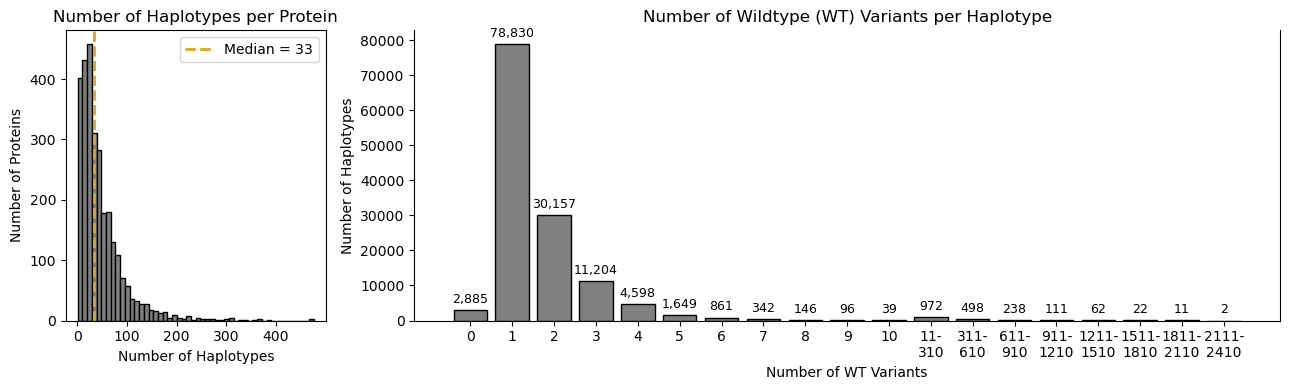

In [7]:
fig1b = hs.plot_haplotypes_summary(haplotypes)

### Figure 1C

Map haplotypes back to samples (individuals).

In [297]:
haps_to_samples = hs.haplotypes_to_samples(haplotypes=haplotypes,  
                                           as_df=True,
                                           add_sample_metadata=True,
                                           return_seqs=False, 
                                           add_ref=False, 
                                           duplicate_ref=False,
                                           verbose=True,
                                           )
haps_to_samples.head()

Extracting sample IDs:   0%|          | 0/2847 [00:00<?, ?it/s]

Number of samples: 3938
Number of transcripts to process: 2847


Processing sample to haplotype name maps:   0%|          | 0/2847 [00:00<?, ?it/s]

Converting haplotypes to DataFrame
Adding sample metadata to the DataFrame
0 samples are missing superpopulation metadata
Samples before merging: 3826
Samples after merging: 3826
Final shape: (19262867, 16)
>> haplotype(s): 132721
>> cohort(s): 3
>> cohort_sample(s): 3938
>> sample(s): 3826
>> population(s): 158
>> superpopulation(s): 8
>> sex(s): 2


,ENST_haplosaurus,cohort_sample,haplotype,cohort,sample,ploid_count,ploid,sex,Biosample ID,Population code,population_name,superpopulation,superpopulation_name,population,Data collections,population_code
0,ENST00000001146,GGVP:SC_GMJOL5309951,ENSP00000001146:264L>S,GGVP,SC_GMJOL5309951,2,0,male,NaN,GWJ,Gambian Jola,AFR,African Ancestry,GWJ,"Gambian Genome Variation Project (GRCh37),Gamb...",NaN
1,ENST00000001146,GGVP:SC_GMJOL5309951,ENSP00000001146:264L>S,GGVP,SC_GMJOL5309951,2,1,male,NaN,GWJ,Gambian Jola,AFR,African Ancestry,GWJ,"Gambian Genome Variation Project (GRCh37),Gamb...",NaN
2,ENST00000001146,1000GENOMES:phase_3:HG02151,ENSP00000001146:REF,1000GENOMES,HG02151,2,0,female,SAME1839403,CDX,Dai Chinese,EAS,East Asian Ancestry,CDX,"1000 Genomes on GRCh38,1000 Genomes 30x on GRC...",NaN
3,ENST00000001146,1000GENOMES:phase_3:HG02151,ENSP00000001146:REF,1000GENOMES,HG02151,2,1,female,SAME1839403,CDX,Dai Chinese,EAS,East Asian Ancestry,CDX,"1000 Genomes on GRCh38,1000 Genomes 30x on GRC...",NaN
4,ENST00000001146,GGVP:SC_GMWOF5428867,ENSP00000001146:REF,GGVP,SC_GMWOF5428867,2,0,female,NaN,GWW,Gambian Wolof,AFR,African Ancestry,GWW,"Gambian Genome Variation Project (GRCh37),Gamb...",NaN


In [298]:
freq_df = hs.calculate_haplotype_frequency_per_superpop(
    haps_to_samples,
    cast=True, 
    verbose=True,
    add_specificity_cols=True
) 
freq_df.head()

0 samples are missing superpopulation metadata

Number of variants specific to each superpopulation:
specific_superpopulation
AFR    35540
EAS    22458
EUR    14917
SAS    13574
AMR     9224
CSA     5134
MID     4439
OCE     1850
Name: count, dtype: int64

Percentage of superpopulation-specific haplotypes: 80.72%


,haplotype,AFR_freq,AMR_freq,CSA_freq,EAS_freq,EUR_freq,MID_freq,OCE_freq,SAS_freq,AFR_samples,AMR_samples,CSA_samples,EAS_samples,EUR_samples,MID_samples,OCE_samples,SAS_samples,top_superpopulation,top_superpopulation_freq,superpopulation_count,specific_superpopulation,specific_superpopulation_samples
0,ENSP00000001146:110H>Y,1.712292e-07,0.0,0.0,0.000000e+00,0.0,0.000000,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,AFR,1.712292e-07,1,AFR,1.0
1,"ENSP00000001146:119R>H,264L>S",2.054751e-06,0.0,0.0,0.000000e+00,0.0,0.000000,0.0,0.0,12.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,AFR,2.054751e-06,1,AFR,12.0
2,ENSP00000001146:123M>V,0.000000e+00,0.0,0.0,0.000000e+00,0.0,0.000001,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,MID,1.240141e-06,1,MID,1.0
3,"ENSP00000001146:140N>I,380E>K",0.000000e+00,0.0,0.0,2.738582e-07,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,EAS,2.738582e-07,1,EAS,1.0
4,ENSP00000001146:143K>R,1.712292e-07,0.0,0.0,0.000000e+00,0.0,0.000000,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,AFR,1.712292e-07,1,AFR,1.0


Extracting sample IDs:   0%|          | 0/2847 [00:00<?, ?it/s]

0 samples are missing superpopulation metadata


/home/schilder/projects/VEP_protein/src/haplosaurus.py:3279: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  samples = get_haplotype_samples(haplotypes, unnest=True, remove_prefix=True)


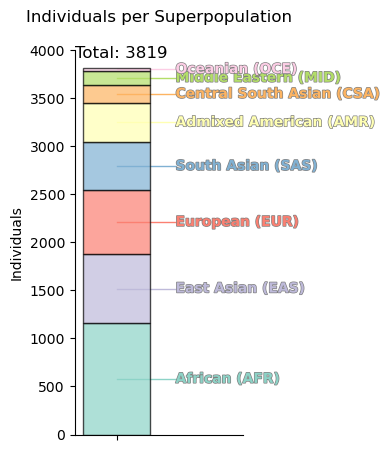

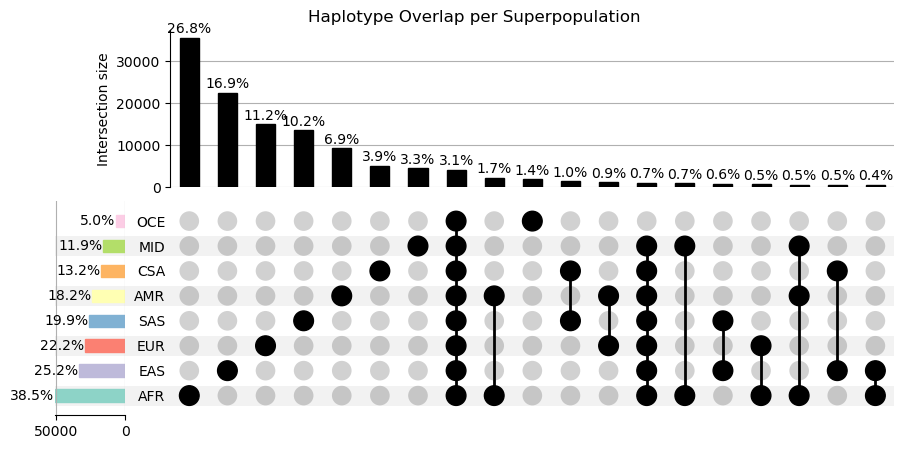

In [10]:
fig1c = hs.plot_haplotypes_and_superpop_bar(freq_df,
                                            haplotypes,
                                            width_ratios=(.2,1), figsize=(13,5))

### Figure 1D

In [4]:
vep_files = va.list_vep_files(as_df=True)

No save_dir provided, using: /home/schilder/projects/data/1KG/vep


Finding VEP files:   0%|          | 0/1 [00:00<?, ?it/s]

Found 893261 parquet files in /home/schilder/projects/data/1KG/vep
Unique values:
>> model_location: 8
scoring_strategy: 3
variant_set: 1
haplotype: 111422
protein: 2251


In [100]:
# Focus on one model for the main plots
model_name = "esm2_t33_650M_UR50D"

vep_df = va.merge_vep(add_metadata=True, 
                      scoring_strategy=["masked-marginals"], 
                      vep_files=vep_files.loc[vep_files['model_location']==model_name]
                           )
vep_df.head() 

No save_dir provided, using: /home/schilder/projects/data/1KG/vep
Found 90773 masked-marginals parquet files


Reading files:   0%|          | 0/90773 [00:00<?, ?it/s]

Concatenating VEP dataframes
Loading ==> /home/schilder/projects/data/haplosaurus/tx_id_map.pkl


Loading '/home/schilder/projects/data/haplosaurus/tx_id_map.pkl': 100%|██████████| 1.70M/1.70M [00:00<00:00, 5.01GB/s]


VEP dataframe shape: (3117366, 72)


,haplotype,protein,protein_sequence,mutant,mutated_sequence,DMS_bin_score,VEP,scoring_strategy,is_ref,model_location,variant_set,ENSP,ENST,mutant_in_haplotype,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,#Uploaded_variation,Location,Allele,Gene,Feature,Feature_type,Consequence,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,IMPACT,DISTANCE,STRAND,FLAGS,REFSEQ_MATCH,REFSEQ_OFFSET,GIVEN_REF,USED_REF,BAM_EDIT,HGVSc,HGVSp,HGVS_OFFSET,AF_ESP,AF_EXAC,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNSIGCONF,CLNVC,CLNVCSO,GENEINFO,MC,ORIGIN,RS,AF_TGP,CLNVI,CLNDISDBINCL,CLNDNINCL,CLNSIGINCL,EVH_epistatic,EVH_independent,ESM1V_ensemble_mean,Tranception,model_count,clinsig
0,ENSP00000262186:1032R>Q,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,L1045F,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Benign,-3.635069,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,7,150947347,67473,G,A,.,PASS,67473,7:150947347,A,3757,NM_000238.4,Transcript,missense_variant,3541,3133,1045,L/F,Ctc/Ttc,-,MODERATE,-,-1,-,-,-,G,G,-,NM_000238.4:c.3133C>T,NP_000229.1:p.Leu1045Phe,-,NaN,0.00000,78369,"MedGen:CN230736|EFO:EFO_0004269,Human_Phenotyp...",Cardiovascular_phenotype|Cardiac_arrhythmia|Co...,NC_000007.14:g.150947347G>A,"criteria_provided,_multiple_submitters,_no_con...",Benign,NaN,single_nucleotide_variant,SO:0001483,KCNH2:3757,SO:0001583|missense_variant,1,199473025,NaN,ClinGen:CA008015,NaN,NaN,NaN,NaN,NaN,-6.731237,-0.021689,6,benign
1,ENSP00000262186:1032R>Q,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,D1003Y,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Pathogenic,-1.670645,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,7,150947473,200516,C,A,.,PASS,200516,7:150947473,A,3757,NM_000238.4,Transcript,missense_variant,3415,3007,1003,D/Y,Gac/Tac,-,MODERATE,-,-1,-,-,-,C,C,-,NM_000238.4:c.3007G>T,NP_000229.1:p.Asp1003Tyr,-,NaN,NaN,197155,MedGen:CN517202,not_provided,NC_000007.14:g.150947473C>A,"criteria_provided,_single_submitter",Likely_pathogenic,NaN,single_nucleotide_variant,SO:0001483,KCNH2:3757,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,794728402,NaN,ClinGen:CA007791,NaN,NaN,NaN,NaN,NaN,-2.509515,-0.039753,6,likely_path
2,ENSP00000262186:1032R>Q,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,N996I,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Pathogenic,-4.619007,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,7,150947493,67458,T,A,.,PASS,67458,7:150947493,A,3757,NM_000238.4,Transcript,missense_variant,3395,2987,996,N/I,aAc/aTc,-,MODERATE,-,-1,-,-,-,T,T,-,NM_000238.4:c.2987A>T,NP_000229.1:p.Asn996Ile,-,NaN,NaN,78354,"MONDO:MONDO:0019171,MedGen:C1141890,OMIM:PS192...",Congenital_long_QT_syndrome|not_provided|Long_...,NC_000007.14:g.150947493T>A,"criteria_provided,_multiple_submitters,_no_con...",Pathogenic/Likely_pathogenic,NaN,single_nucleotide_variant,SO:0001483,KCNH2:3757,"SO:0001583|missense_variant,SO:0001619|non-cod...",1,199473018,NaN,ClinGen:CA007728|UniProtKB:Q12809#VAR_068285,NaN,NaN,NaN,NaN,NaN,-5.869637,-0.057342,6,likely_path
3,ENSP00000262186:1032R>Q,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,E978K,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Benign,-0.514701,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,7,150947639,67453,C,T,.,PASS,67453,7:150947639,T,3757,NM_000238.4,Transcript,missense_variant,3340,2932,978,E/K,Gag/Aag,-,MODERATE,-,-1,-,-,-,C,C,-,NM_000238.4:c.2932G>A,NP_000229.1:p.Glu978Lys,-,0.00008,0.00039,78349,"EFO:EFO_0004269,Human_Phenotype_Ontology:HP:00...",Cardiac_arrhythmia|Cardiovascular_phenotype|no...,NC_000007.14:g.150947639C>T,"criteria_provided,_multiple_submitters,_no_con...",Likely_benign,NaN,single_nucleotide_variant,SO:0001483,KCNH2:3

  0%|          | 0/2525 [00:00<?, ?it/s]

Extracting ID columns.
Using default maps.
Simplifying annotations.
      ClinSig  Count       Source Consequence    Consequence (Source)
0      benign   2615  SpliceVarDB    Splicing  Splicing (SpliceVarDB)
1  pathogenic   3327  SpliceVarDB    Splicing  Splicing (SpliceVarDB)
0      benign  11718      ClinVar         UTR           UTR (ClinVar)
1  pathogenic   2053      ClinVar         UTR           UTR (ClinVar)
0      benign  30727   ProteinGym    Missense   Missense (ProteinGym)
1  pathogenic  32000   ProteinGym    Missense   Missense (ProteinGym)


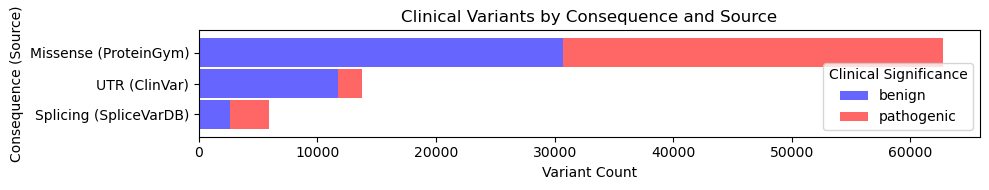

In [7]:
fig1d = va.variant_count_by_source_barplot(show_plot=True)

### Figure 1E

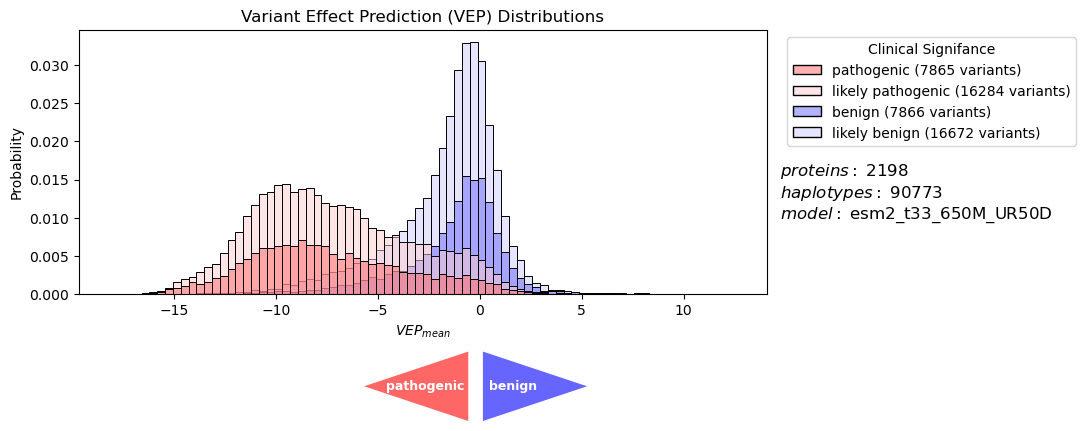

In [119]:
fig1e = db.plot_vep_histogram_with_arrows(vep_df, model_name=model_name,  
                                          arrow_y= -0.35,
                                          arrow_head_length=0.047,
                                          arrow_length=.19,
                                          figsize=(11, 4),
                                          arrow_text_fontsize=9,
                                          external_legend_annotation=True)

### Figure 1F

<string>:60: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
<string>:91: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


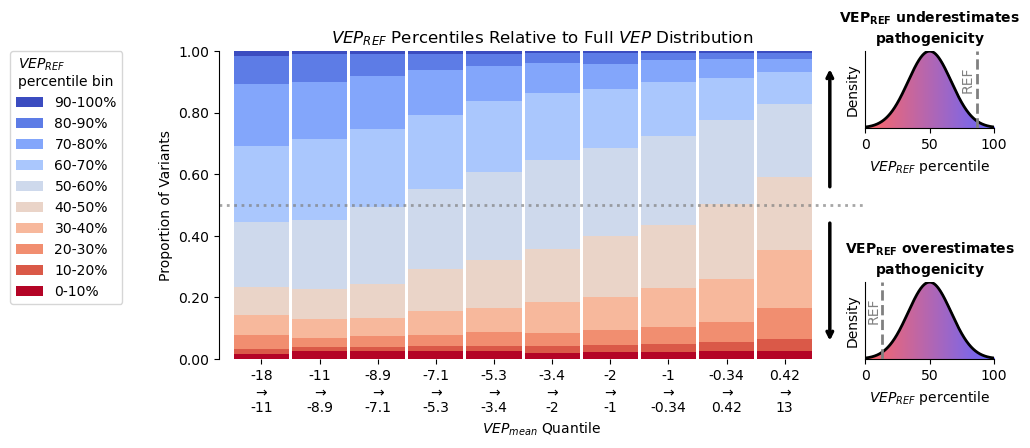

In [117]:
#### Percentile barplot version #### 
fig1f_pct = db.plot_ref_vep_percentile_stacked_bar(vep_df,
                                                    figsize=(10, 4), 
                                                    barplot_width_ratio=5,
                                                        schematic_width_ratio=1,
                                                        schematic_padding=0.001,
                                                    schematic_heights=[0.25, 0.50, 0.25]
                                                    )

In [169]:
# For each group, get the "VEP" value for the row where is_ref==True
groupby_cols = ['model_location','protein','clinsig','mutant','scoring_strategy']
ref_vep = vep_df.loc[vep_df["is_ref"]].set_index(groupby_cols)["VEP"]
vep_df["VEP_REF"] = vep_df.set_index(groupby_cols).index.map(ref_vep)
vep_df["VEP_ref_diff"] = vep_df["VEP_REF"] - vep_df["VEP"]

## Figure 2

In [44]:
uniprot_gene = "BRCA1" # DYPD
uniprot_ids = {"BRCA1":"P38398", "DYPD":"Q12882"}
uniprot_id = uniprot_ids[uniprot_gene]

In [ ]:
import src.colabfold.colabfold as cf
import numpy as np

structure = cf.import_mmcif(protein_id = uniprot_id)[0]

contact_map = cf.get_contact_map(structure, 
                                 max_distance=8.0, 
                                 continuous=True, 
                                 return_distance_map=True )

File /home/schilder/.cache/alphafold_db/cif/AF-P38398-F1-model_v4.cif already exists, skipping download.


In [ ]:
refseq_ids = ['NP_009225.1'] # BRCA1
# refseq_ids = ['NP_000101.2'] # DYPD 

model_name = "esm2_t33_650M_UR50D"

vep_prot = va.merge_vep(
    scoring_strategy=["masked-marginals"],
    vep_files=vep_files.loc[(vep_files['model_location']==model_name) & 
                            (vep_files['protein'].isin(refseq_ids))]
    )
print("n_haplotypes: ", vep_prot["haplotype"].nunique())
vep_prot["HGNC"] = vep_prot["GENEINFO"].str.split(":").str[0] 
vep_prot['site'] = vep_prot['protein'] + ":" + vep_prot['mutant'] 


No save_dir provided, using: /home/schilder/projects/data/1KG/vep
Found 144 masked-marginals parquet files


Reading files:   0%|          | 0/144 [00:00<?, ?it/s]

Concatenating VEP dataframes
Loading ==> /home/schilder/projects/data/haplosaurus/tx_id_map.pkl


Loading '/home/schilder/projects/data/haplosaurus/tx_id_map.pkl': 100%|██████████| 1.70M/1.70M [00:00<00:00, 2.40GB/s]


VEP dataframe shape: (65664, 72)
n_haplotypes:  144


Contact enrichment for BRCA1 WT vs. Clinical variant interactions.

In [ ]:
contact_map_binary = cf.get_contact_map(structure, 
                                        max_distance=8.0, 
                                        continuous=False, 
                                        return_distance_map=False )

Use ridge regression to find WT-Clinical variant interactions.

In [ ]:
wtvariants_to_vep_linear_model_out = ab.wtvariants_to_vep_linear_model(vep_df=vep_prot,
                                                          alpha=1)  
ridge_df = wtvariants_to_vep_linear_model_out["interaction_df"]

vep_matrix shape:  (144, 456)
wt_matrix shape:  (144, 132)
Dropped 1 haplotypes due to NaNs in input or target matrices.


In [ ]:
# Choose a threshold for the interaction strength and compute the contact enrichment at that specific threshold.
# Then plot the contact map and the sensitization map.

### Figure 2A

Toy schematic of variant sensitization maps methodology (ridge regression method).

<string>:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


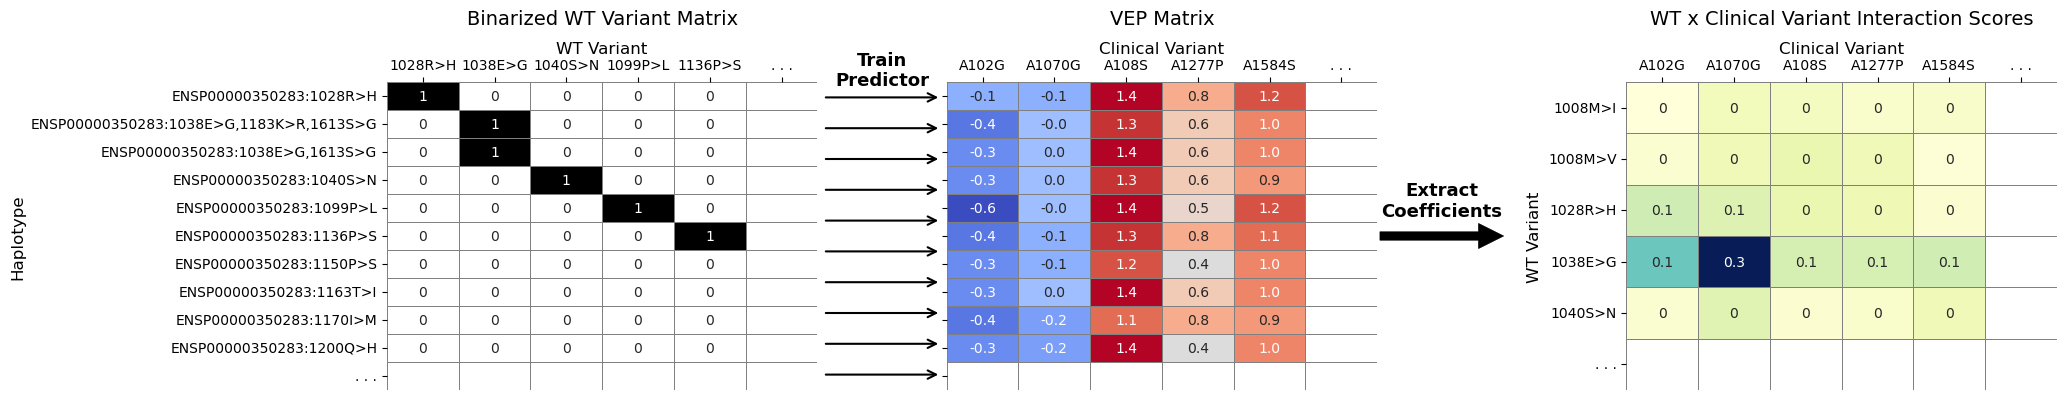

In [403]:
fig2a = ab.plot_variant_sensitization_schematic(wtvariants_to_vep_linear_model_out)


### Figure 2B

BRCA1 AlphaFold contact map (reference sequence).

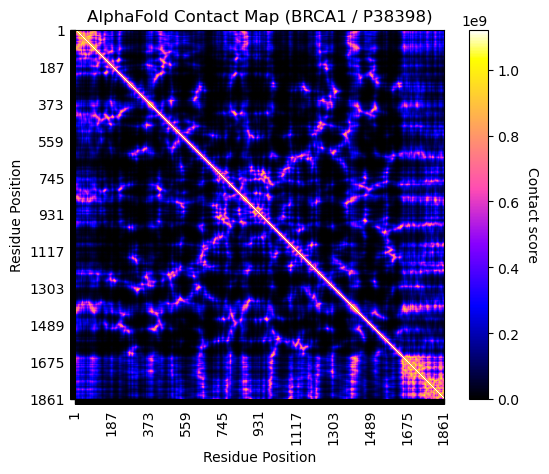

In [45]:
contact_map, contact_map_binned = cf.plot_contact_map(contact_map=contact_map, 
                    title=f"AlphaFold Contact Map ({uniprot_gene} / {uniprot_id})",  
                    bin_size=1,   
                    pow=4, 
                    agg_func=np.nanmax)

### Figure 2C

BRCA1 sensitization map (aligned) +  BRCA1 AlphaFold contact map (reference sequence).

In [3]:
if "vep_files" not in globals():
    vep_files = va.list_vep_files(as_df=True)

No save_dir provided, using: /home/schilder/projects/data/1KG/vep


Finding VEP files:   0%|          | 0/1 [00:00<?, ?it/s]

Found 897805 parquet files in /home/schilder/projects/data/1KG/vep
Unique values:
>> model_location: 8
scoring_strategy: 3
variant_set: 1
haplotype: 111422
protein: 2251


In [221]:
interaction_threshold = 0.05

top_interactions = ridge_df.loc[ridge_df["interaction_strength"] > interaction_threshold]    

ridge_enrichment_at_threshold = ab.compute_enrichment_vs_threshold(
    outlier_df=ridge_df,
    contact_map_binary=contact_map_binary, 
    thresholds=[interaction_threshold],
    linear_sampling=False,  
    interaction_col="interaction_strength"
)

print()
print(f"Number of top interactions: {top_interactions.shape[0]}" + \
      f" ({top_interactions.shape[0] / ridge_df.shape[0]*100:.2f}% of all WT-Clinical variant pairs)")
print(f"Enrichment at threshold {interaction_threshold}: {ridge_enrichment_at_threshold['enrichment'].values[0]:.2f}x" )

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00, 26.73it/s]


Number of top interactions: 518 (0.86% of all WT-Clinical variant pairs)
Enrichment at threshold 0.05: 59.72x


(1863, 1863)
Adding rectangles


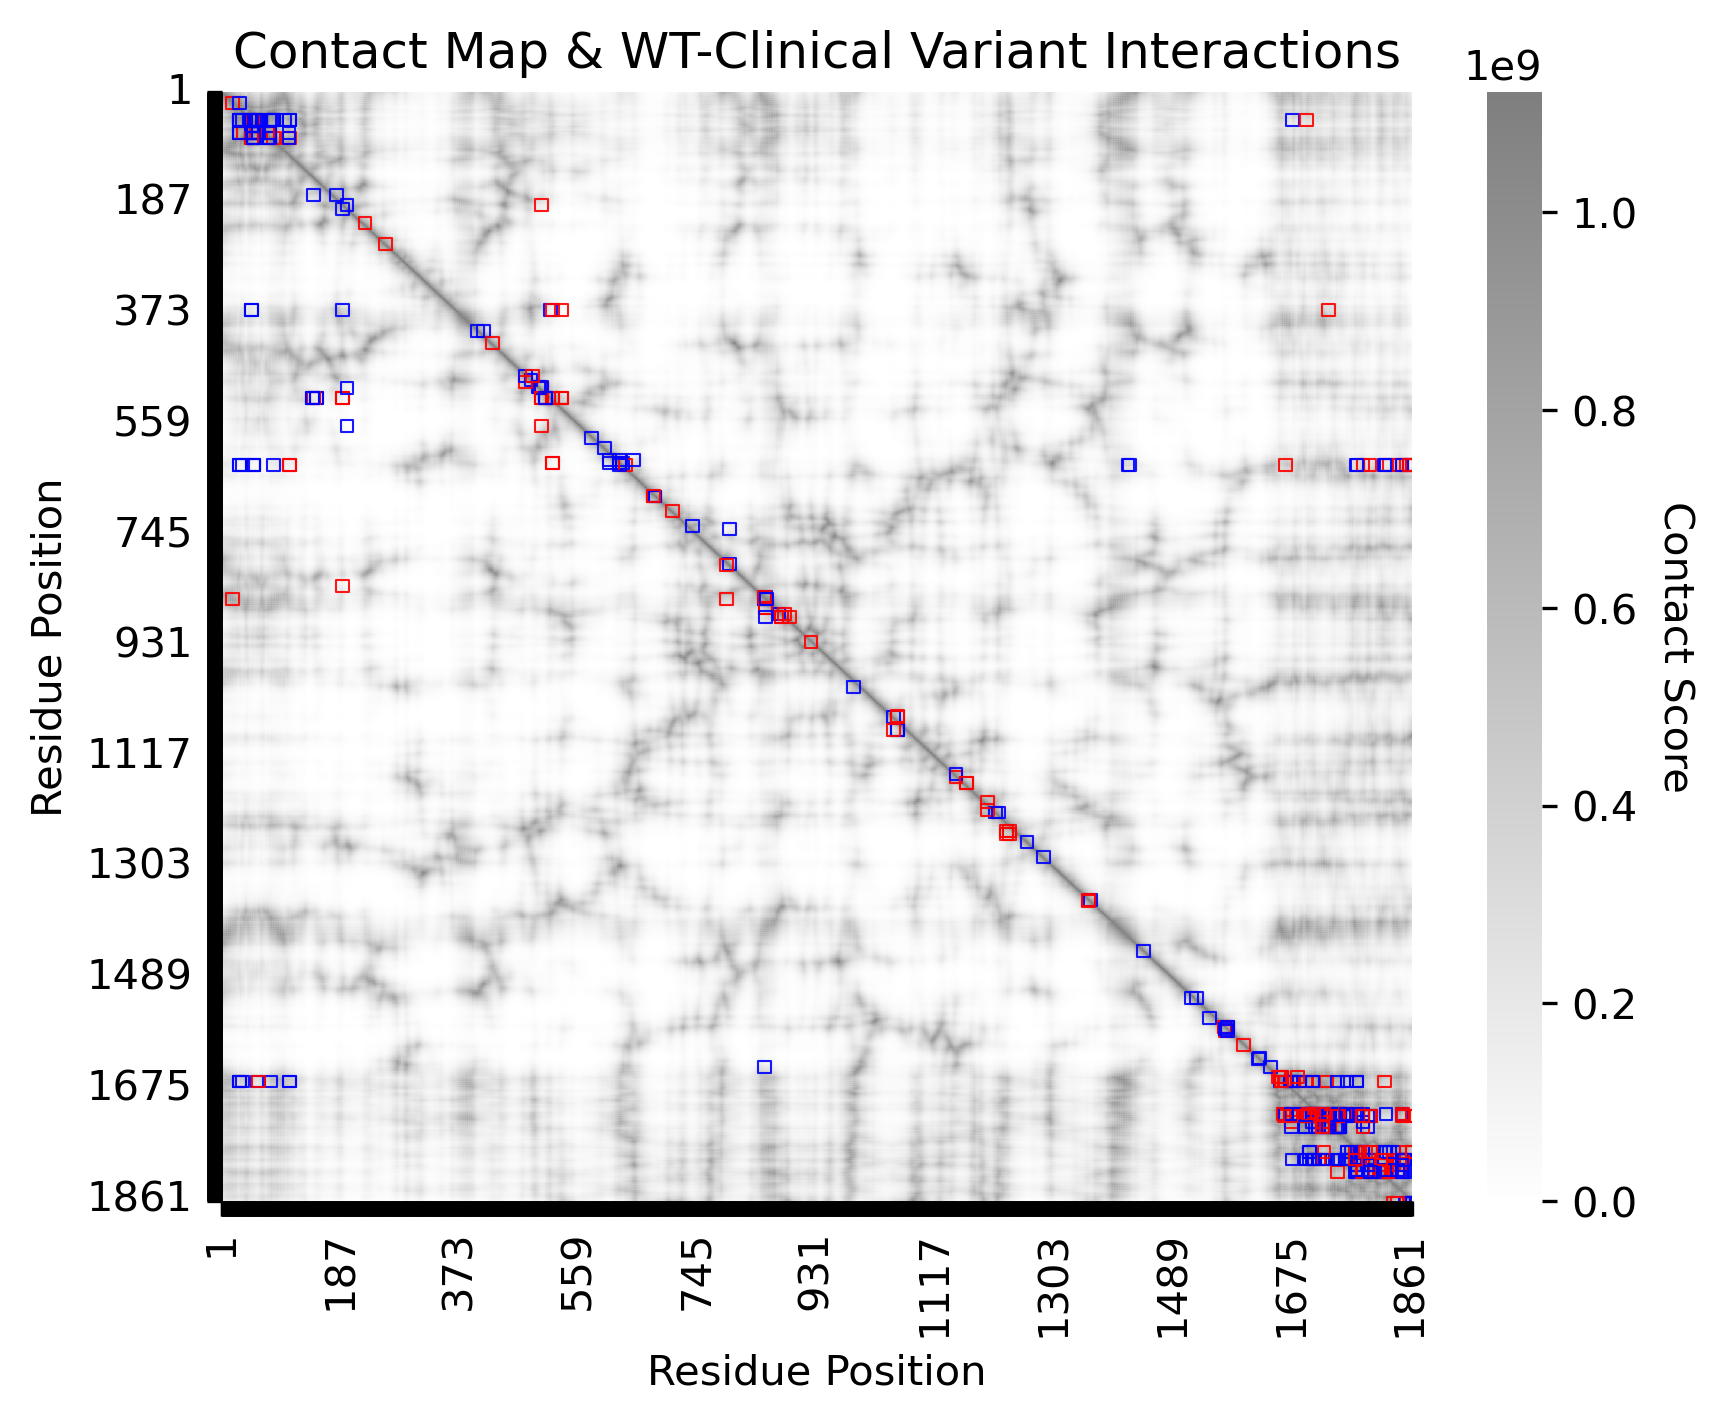

In [ ]:
plot_contact_and_sensitization_maps_out = ab.plot_contact_and_sensitization_maps(
    contact_map_binned=contact_map_binned,
    outlier_sig=top_interactions, 
    rectangles_cmap={"more pathogenic": "red", "more benign": "blue", "neutral": "grey"},
    title=rf"Contact Map & WT-Clinical Variant Interactions",# +"\n"+rf"(Interaction Strength $\geq$ {interaction_threshold})",
    show_plot=(False, True),
    # figsize=(10, 10)
)

### Figure 2D

Contact enrichment: outlier detection method

In [202]:
ridge_enrichment = ab.compute_enrichment_vs_threshold(
    outlier_df=ridge_df,
    contact_map_binary=contact_map_binary, 
    num_thresholds=50,
    linear_sampling=False,  
    interaction_col="interaction_strength"
)

  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [00:02<00:00, 18.58it/s]


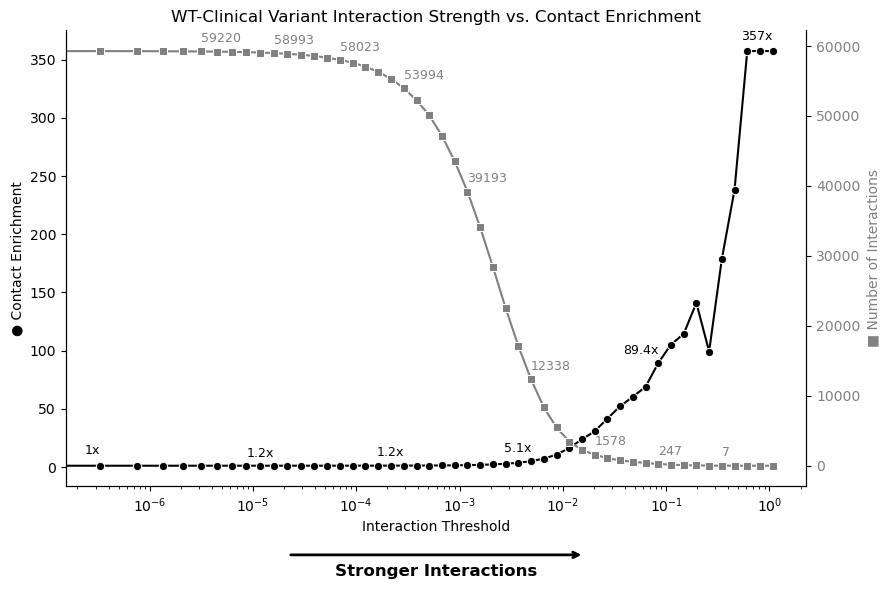

In [265]:
fig2d = ab.plot_enrichment_vs_interactions(ridge_enrichment,   
                                   log_x_axis=True, 
                                   y1_first_label=True,
                                   y1_last_label=True,
                                   y2_first_label=True,
                                   y2_last_label=True, )

In [226]:
### Figure 2D

In [ ]:
# Mean interaction strength per clinical variant.

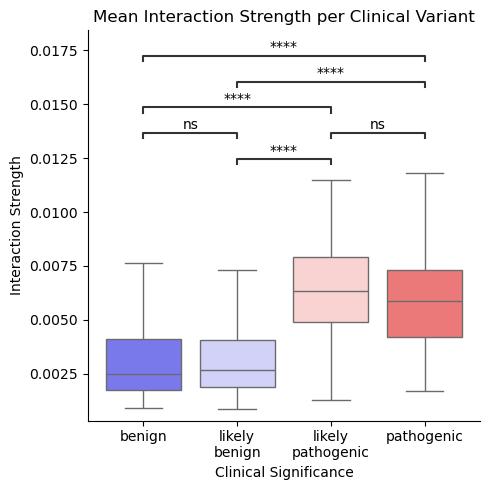

In [271]:
fig2e = ab.plot_clinsig_interaction_strength(
    ridge_df, vep_prot,
    title="Mean Interaction Strength per Clinical Variant",
    xlabel="Clinical Significance",
    ylabel="Interaction Strength", 
    text_format="star",
    figsize=(5, 5),
)

---

---

## Figure S1

Plot VEP distributions for each combination of model and scoring strategy.

Protein sequence models.

In [ ]:
groupby_cols = ['model_location','protein','clinsig','mutant','scoring_strategy']

vep_agg =[]
for model_location in vep_files["model_location"].unique():
    vep_tmp = va.merge_vep(add_metadata=True, 
                            # scoring_strategy=["masked-marginals"], 
                            vep_files=vep_files.loc[vep_files['model_location']==model_location]
                               )
    vep_agg.append(vep_tmp.groupby(groupby_cols, observed=True)["VEP"].mean().reset_index())
    break 

vep_agg = pd.concat(vep_agg)
vep_agg.head()

Filtered 0.5% of rows with NAs in col 'VEP'


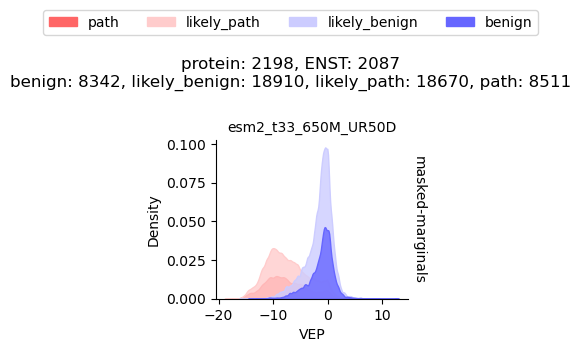

In [150]:
va.plot_vep_density(vep_agg, 
                     multiple=['layer','stack','fill'][0],
                     row='scoring_strategy',
                     col='model_location',    
                     legend_y=1.1,
                     aspect=1,
                     save_path="results/plots/vep_density.png"
                     )

DNA sequence models.

## Figure S2

In [265]:
vep_df = va.compute_representativeness_stats(vep_df, is_ref=False)

In [278]:
vep_df["n_haplotypes"] = vep_df.groupby(["model_location", "scoring_strategy", "mutant"])["haplotype"].transform("nunique")

In [ ]:
#### Violin plot version ####
# fig1f_vio = db.plot_vep_percentiles(vep_df, row=None, col=None, height=5, aspect=1.5, x_rotation=0, x_ha='center')

In [ ]:
groupby_cols = ['model_location','protein','clinsig','mutant','scoring_strategy']
normality_results = db.test_normality(vep_df,
                                      min_n=20,
                                      groupby_cols=groupby_cols)
normality_results.head()

  0%|          | 0/54433 [00:00<?, ?it/s]

metric,model_location,protein,clinsig,mutant,scoring_strategy,n_samples,pvalue,statistic
0,esm2_t33_650M_UR50D,NP_000007.1,benign,C159W,masked-marginals,26.0,0.288377,2.486977
1,esm2_t33_650M_UR50D,NP_000007.1,likely_benign,M87I,masked-marginals,26.0,0.000002,25.841743
2,esm2_t33_650M_UR50D,NP_000007.1,likely_path,A113T,masked-marginals,26.0,0.008392,9.560975
3,esm2_t33_650M_UR50D,NP_000007.1,likely_path,A165T,masked-marginals,26.0,0.000017,21.954090
4,esm2_t33_650M_UR50D,NP_000007.1,likely_path,A81T,masked-marginals,26.0,0.001276,13.327450


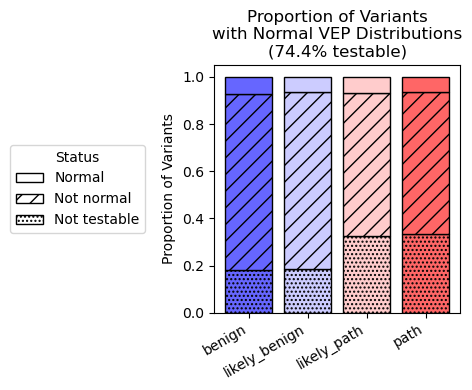

In [ ]:
plot_test_normality_out = db.plot_test_normality(normality_results, 
                                                 figsize=(5, 4), 
                                                 legend_left=True, 
                                                 )

<string>:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


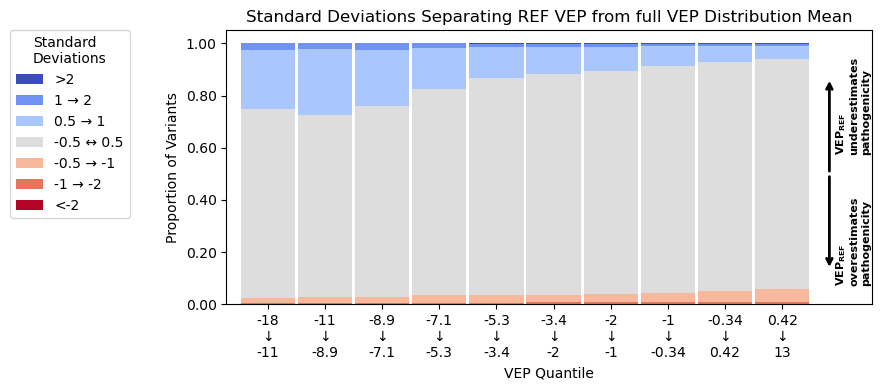

In [ ]:
#### Standard Deviation version ####

# Limit to variants with normal VEP distributions
groupby_cols = ['model_location','protein','clinsig','mutant','scoring_strategy']
vep_sub = vep_df.merge(
    normality_results.loc[normality_results["pvalue"] >= 0.05],
    on=groupby_cols,
    how="left"
) 
fig1f_std = db.plot_ref_vep_std_stacked_bar(vep_sub)

In [ ]:
fig1f_std['data'].groupby('VEP_pct_group_cat').size() / fig1f_std['data'].groupby('VEP_pct_group_cat').size().sum()*100

/tmp/ipykernel_3060468/3121036080.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fig1f['data'].groupby('VEP_pct_group_cat').size() / fig1f['data'].groupby('VEP_pct_group_cat').size().sum()*100
/tmp/ipykernel_3060468/3121036080.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fig1f['data'].groupby('VEP_pct_group_cat').size() / fig1f['data'].groupby('VEP_pct_group_cat').size().sum()*100


VEP_pct_group_cat
<-2            0.444569
-1 → -2        7.336782
-0.5 → -1     17.570250
-0.5 ↔ 0.5    59.183559
0.5 → 1       10.703201
1 → 2          4.504404
>2             0.257235
dtype: float64

## Figure S3

Sampling 6 rows from 5
                                  mutant  protein
model_location  scoring_strategy                 
esm3_sm_open_v1 masked-marginals       5        4


<string>:92: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
<string>:156: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


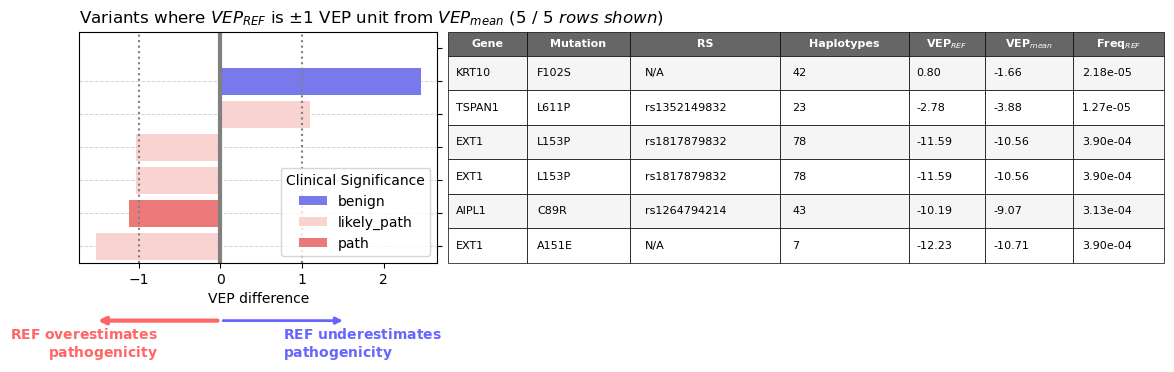

(<Axes: title={'left': 'Variants where $\\it{VEP_{REF}}$ is $\\pm$1 VEP unit from $\\it{VEP_{mean}}$$\\it{\\ (5\\ /\\ 5\\ rows\\ shown)}$'}, xlabel='VEP difference'>,
 <Axes: >)

In [458]:
va.plot_top_diff_variants(vep_df, 
                          freq_df, 
                          x="VEP_mean_diff", 
                          title=  r"Variants where $\it{VEP_{REF}}$ is $\pm$1 VEP unit from $\it{VEP_{mean}}$",
                          max_rows=6,
                          figsize=(14, None),
                          sample_head_and_tail=True,
                          arrow_bottom_margin=0.25,
                          arrow_text_padding=0.025,
                          table_width_ratio=2,
                          is_ref_filter=True)

Sampling 6 rows from 695
                                  mutant  protein
model_location  scoring_strategy                 
esm3_sm_open_v1 masked-marginals       6        5


<string>:91: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
<string>:155: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


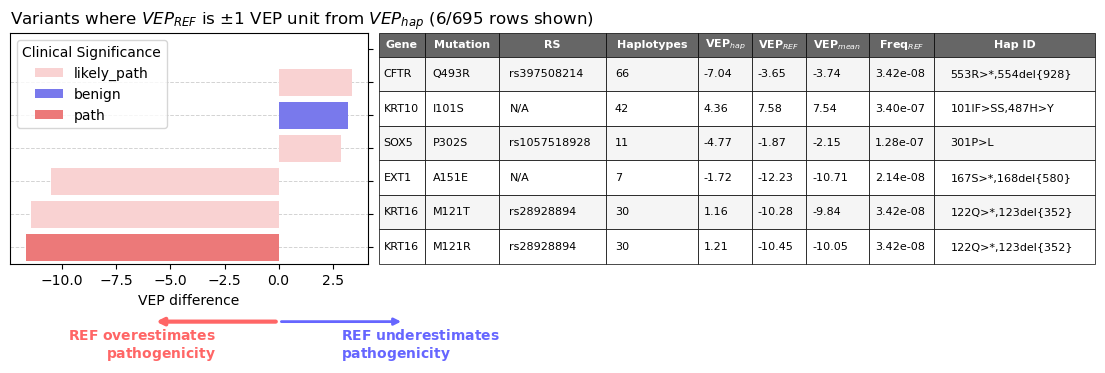

(<Axes: title={'left': 'Variants where $\\it{VEP_{REF}}$ is $\\pm$1 VEP unit from $\\it{VEP_{hap}}$ (6/695 rows shown)'}, xlabel='VEP difference'>,
 <Axes: >)

In [452]:
va.plot_top_diff_variants(vep_df, 
                          freq_df, 
                          x="VEP_ref_diff", 
                          title=  r"Variants where $\it{VEP_{REF}}$ is $\pm$1 VEP unit from $\it{VEP_{hap}}$",
                          max_rows=6,
                          figsize=(14, None),
                          sample_head_and_tail=True,
                          arrow_bottom_margin=0.25,
                          arrow_text_padding=0.025,
                          table_width_ratio=2,
                          is_ref_filter=None)

In [460]:
import matplotlib.pyplot as plt

# Create bins: '<-1', '-1 to 1', '>1'
bins = pd.cut(
    vep_df.loc[~vep_df["is_ref"], "VEP_ref_diff"],
    bins=[-float('inf'), -1, 1, float('inf')],
    labels=['<-1', '-1 to 1', '>1']
)
bin_counts = bins.value_counts().sort_index()
bin_counts
 

VEP_ref_diff
<-1           520
-1 to 1    521287
>1            180
Name: count, dtype: int64